# 04 Hyperparameter Tuning

## Business Objective

This notebook tests whether the Phase 1 LightGBM baseline for next-day terminal dwell forecasting can be improved through careful hyperparameter tuning.

The goal is not to change the business framing or introduce a different model. Instead, the goal is to evaluate whether alternative LightGBM settings can reduce prediction error while preserving the same operational forecasting problem and feature structure established in the baseline notebooks.

In [1]:
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("Imports OK")

Imports OK


## Load and prepare the Phase 1 dataset

This notebook reuses the same synthetic terminal dwell dataset, target variable, and feature structure used in the baseline modeling workflow. This keeps the tuning exercise directly comparable to the baseline model.

In [2]:
project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "synthetic" / "phase1_terminal_dwell.csv"

df = pd.read_csv(data_path, parse_dates=["date"])
df.columns = df.columns.str.strip()
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)

print("Data path:", data_path)
print("Shape:", df.shape)

df.head()

Data path: /home/jorge/projects/rail-ops-forecaster/data/synthetic/phase1_terminal_dwell.csv
Shape: (8760, 13)


,date,terminal_id,terminal_name,region,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,target_dwell_hours
0,2022-01-01,T01,Barstow,West,13,304,532,59.100,13,92.300,1,1,19.700
1,2022-01-02,T01,Barstow,West,11,223,461,51.200,11,95.300,1,1,19.500
2,2022-01-03,T01,Barstow,West,10,219,448,49.800,18,85.700,0,1,20.000
3,2022-01-04,T01,Barstow,West,7,138,350,38.900,14,88.500,0,1,20.400
4,2022-01-05,T01,Barstow,West,9,175,361,40.100,17,90.500,0,1,20.700


In [3]:
target_col = "target_dwell_hours"

feature_cols = [
    "terminal_id",
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Number of features:", len(feature_cols))
print("Target column:", target_col)
print("Features:")
for col in feature_cols:
    print("-", col)

Number of features: 9
Target column: target_dwell_hours
Features:
- terminal_id
- inbound_train_count
- inbound_car_count
- cars_on_hand
- yard_occupancy_pct
- crew_starts_available
- locomotive_availability_pct
- is_weekend
- month


In [4]:
split_date = "2024-07-01"

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train_full = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train_full = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Train full shape:", X_train_full.shape)
print("Test shape:", X_test.shape)
print("Train date range:", df.loc[train_mask, "date"].min(), "to", df.loc[train_mask, "date"].max())
print("Test date range:", df.loc[test_mask, "date"].min(), "to", df.loc[test_mask, "date"].max())

Train full shape: (7296, 9)
Test shape: (1464, 9)
Train date range: 2022-01-01 00:00:00 to 2024-06-30 00:00:00
Test date range: 2024-07-01 00:00:00 to 2024-12-30 00:00:00


## Create a validation split from the training period

To tune the model without leaking information from the final test set, the training period is split again into an earlier training subset and a later validation subset. The validation set is used to compare parameter combinations, and the final test set remains untouched until the end.

In [5]:
validation_start = "2024-01-01"

train_sub_mask = df.loc[train_mask, "date"] < validation_start
valid_sub_mask = df.loc[train_mask, "date"] >= validation_start

X_train_sub = X_train_full.loc[train_sub_mask].copy()
X_valid = X_train_full.loc[valid_sub_mask].copy()
y_train_sub = y_train_full.loc[train_sub_mask].copy()
y_valid = y_train_full.loc[valid_sub_mask].copy()

X_train_sub["terminal_id"] = X_train_sub["terminal_id"].astype("category")
X_valid["terminal_id"] = X_valid["terminal_id"].astype("category")
X_test["terminal_id"] = X_test["terminal_id"].astype("category")

print("Train subset shape:", X_train_sub.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

Train subset shape: (5840, 9)
Validation shape: (1456, 9)
Test shape: (1464, 9)


## Define a small tuning grid

The goal of this section is to test a small number of LightGBM parameter combinations in a controlled and interpretable way. Rather than running a large automated search, this notebook uses a small manual grid so that the impact of each setting can be understood clearly.

In [6]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.10],
    "num_leaves": [15, 31, 63],
    "min_child_samples": [10, 20]
}

param_combinations = list(itertools.product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["num_leaves"],
    param_grid["min_child_samples"]
))

print("Number of parameter combinations:", len(param_combinations))
param_combinations[:5]

Number of parameter combinations: 54


[(200, 0.03, 15, 10),
 (200, 0.03, 15, 20),
 (200, 0.03, 31, 10),
 (200, 0.03, 31, 20),
 (200, 0.03, 63, 10)]

In [7]:
def evaluate_lgbm(params, X_train, y_train, X_valid, y_valid):
    model = LGBMRegressor(
        objective="regression",
        random_state=42,
        **params
    )
    
    model.fit(
        X_train,
        y_train,
        categorical_feature=["terminal_id"]
    )
    
    y_valid_pred = model.predict(X_valid)
    
    mse = mean_squared_error(y_valid, y_valid_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_valid, y_valid_pred)
    
    return rmse, mae

In [8]:
results = []

for n_estimators, learning_rate, num_leaves, min_child_samples in param_combinations:
    params = {
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "num_leaves": num_leaves,
        "min_child_samples": min_child_samples
    }
    
    rmse_valid, mae_valid = evaluate_lgbm(
        params,
        X_train_sub,
        y_train_sub,
        X_valid,
        y_valid
    )
    
    results.append({
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "num_leaves": num_leaves,
        "min_child_samples": min_child_samples,
        "rmse_valid": rmse_valid,
        "mae_valid": mae_valid
    })

results_df = pd.DataFrame(results).sort_values("rmse_valid").reset_index(drop=True)

print("Tuning complete.")
results_df.head(10)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1062
[LightGBM] [Info] Number of data points in the train set: 5840, number of used features: 9
[LightGBM] [Info] Start training from score 19.167911
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1062
[LightGBM] [Info] Number of data points in the train set: 5840, number of used features: 9
[LightGBM] [Info] Start training from score 19.167911
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1062
[LightGBM] [Info] Number of data points in the train set: 5840, number of used features: 9
[LightGBM] [Info] Start trainin

,n_estimators,learning_rate,num_leaves,min_child_samples,rmse_valid,mae_valid
0,200,0.030,15,20,3.637,2.801
1,200,0.030,15,10,3.642,2.806
2,200,0.050,15,10,3.642,2.813
3,300,0.030,15,10,3.644,2.811
4,300,0.030,15,20,3.648,2.813
5,200,0.050,15,20,3.649,2.817
6,300,0.050,15,10,3.652,2.825
7,200,0.030,31,10,3.654,2.819
8,300,0.050,15,20,3.657,2.828
9,500,0.030,15,10,3.658,2.829


In [9]:
best_params = results_df.iloc[0][
    ["n_estimators", "learning_rate", "num_leaves", "min_child_samples"]
].to_dict()

print("Best parameter combination:")
print(best_params)

print("\nBest validation RMSE:", results_df.iloc[0]["rmse_valid"])
print("Best validation MAE:", results_df.iloc[0]["mae_valid"])

Best parameter combination:
{'n_estimators': 200.0, 'learning_rate': 0.03, 'num_leaves': 15.0, 'min_child_samples': 20.0}

Best validation RMSE: 3.6366406367230764
Best validation MAE: 2.800556578073803


In [10]:
best_row = results_df.sort_values("rmse_valid", ascending=True).iloc[0]

best_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "learning_rate": float(best_row["learning_rate"]),
    "num_leaves": int(best_row["num_leaves"]),
    "min_child_samples": int(best_row["min_child_samples"]),
}

print("Best parameters (programmatically extracted):")
print(best_params)

X_train_full_tuned = X_train_full.copy()
X_test_tuned = X_test.copy()

X_train_full_tuned["terminal_id"] = X_train_full_tuned["terminal_id"].astype("category")
X_test_tuned["terminal_id"] = X_test_tuned["terminal_id"].astype("category")

tuned_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    **best_params
)

tuned_model.fit(
    X_train_full_tuned,
    y_train_full,
    categorical_feature=["terminal_id"]
)

y_test_pred_tuned = tuned_model.predict(X_test_tuned)

mse_test_tuned = mean_squared_error(y_test, y_test_pred_tuned)
rmse_test_tuned = mse_test_tuned ** 0.5
mae_test_tuned = mean_absolute_error(y_test, y_test_pred_tuned)

print(f"Tuned test RMSE: {rmse_test_tuned:.3f}")
print(f"Tuned test MAE: {mae_test_tuned:.3f}")

Best parameters (programmatically extracted):
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 20}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1066
[LightGBM] [Info] Number of data points in the train set: 7296, number of used features: 9
[LightGBM] [Info] Start training from score 19.060458
Tuned test RMSE: 3.749
Tuned test MAE: 2.879


In [11]:
baseline_rmse = 3.841
baseline_mae = 2.942

comparison_df = pd.DataFrame({
    "model": ["Baseline LightGBM", "Tuned LightGBM"],
    "RMSE": [baseline_rmse, rmse_test_tuned],
    "MAE": [baseline_mae, mae_test_tuned]
})

comparison_df["RMSE_improvement_vs_baseline"] = baseline_rmse - comparison_df["RMSE"]
comparison_df["MAE_improvement_vs_baseline"] = baseline_mae - comparison_df["MAE"]

comparison_df

,model,RMSE,MAE,RMSE_improvement_vs_baseline,MAE_improvement_vs_baseline
0,Baseline LightGBM,3.841,2.942,0.000,0.000
1,Tuned LightGBM,3.749,2.879,0.092,0.063


In [12]:
rmse_pct_improvement = ((baseline_rmse - rmse_test_tuned) / baseline_rmse) * 100
mae_pct_improvement = ((baseline_mae - mae_test_tuned) / baseline_mae) * 100

print(f"RMSE improvement vs baseline: {rmse_pct_improvement:.2f}%")
print(f"MAE improvement vs baseline: {mae_pct_improvement:.2f}%")

RMSE improvement vs baseline: 2.39%
MAE improvement vs baseline: 2.12%


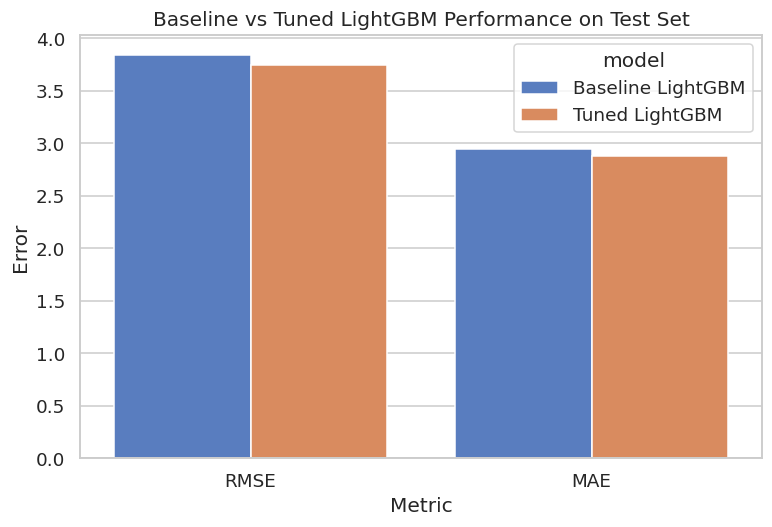

In [13]:
comparison_plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=["RMSE", "MAE"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_plot_df, x="metric", y="value", hue="model")
plt.title("Baseline vs Tuned LightGBM Performance on Test Set")
plt.ylabel("Error")
plt.xlabel("Metric")
plt.show()

## Interpretation of tuning results

The tuning exercise tested a small set of LightGBM parameter combinations using a validation split taken from the training period. The best-performing configuration used fewer trees, a lower learning rate, and a smaller leaf structure than the original baseline.

The next comparison evaluates whether those validation gains carry over to the untouched test set. If the tuned model improves test RMSE and MAE relative to the baseline, that suggests the original model had room for performance improvement through more careful parameter selection. If the gains are small, the baseline may already have been reasonably well specified for this synthetic Phase 1 problem.

Note that modest tuning gains are not unexpected here. The baseline was already conservatively specified, and the synthetic dataset contains a component of random noise — including congestion-spike events — that no parameter configuration can reduce. Any remaining gap between the tuned and baseline scores likely reflects this irreducible variance rather than under-tuning.

## Conclusion

The hyperparameter tuning exercise produced a modest but measurable improvement over the original LightGBM baseline. The best configuration used fewer trees, a lower learning rate, and a smaller leaf structure than the baseline model, suggesting that a slightly more conservative model generalized better to unseen data.

On the final test set, the tuned model improved RMSE from **3.841** to **3.749** and MAE from **2.942** to **2.879** relative to the standardized Notebook 02 baseline. These gains are not large, which indicates that the original baseline was already reasonably well specified. However, the improvement is still meaningful because it was achieved through a disciplined validation-based tuning process without changing the business framing or using the test set for model selection.

Overall, this notebook shows that the Phase 1 terminal dwell forecasting model can be improved incrementally through careful tuning, while preserving the same operational feature set and forecasting objective. The next step is to examine model errors more closely to understand where the tuned model performs well, where it still struggles, and what types of terminal conditions are associated with larger misses.